## Packages & Functions

### Import packages

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import savgol_filter
from brukeropus import read_opus
from pybaselines import Baseline, utils
import plotly.express as px
import plotly.graph_objects as go

### Load Functions

In [3]:
def get_list_of_opus_files(files_dir):
    '''
    Returns a list of OPUS files in the specified directory.
    '''
    list_of_files = os.listdir(files_dir)
    opus_files = [file for file in list_of_files if file[-2] == '.' and file[-1].isdigit()]
    return opus_files

def get_from_opus(opus_file):
    '''
    Extracts the Absorbance data from an OPUS file and returns it as a dictionary
    containing a DataFrame sorted by ascending wavenumber.
    '''
    if 'a' in opus_file.data_keys:
        x, y = opus_file.a.x, opus_file.a.y
    elif 'atr' in opus_file.data_keys:
        x, y = opus_file.atr.x, opus_file.atr.y
    else:
        print(f"Warning: no Absorbance data found. Available keys: {opus_file.data_keys}")
        return None
    
    abs_df = pd.DataFrame({'wvn': x, 'abs': y}).dropna(how='any')
    abs_df.sort_values('wvn', inplace=True)
    abs_df.reset_index(drop=True, inplace=True)

    if 'rf' in opus_file.data_keys:
        ref_x, ref_y = opus_file.rf.x, opus_file.rf.y
        ref_df = pd.DataFrame({'wvn': ref_x, 'ref': ref_y}).dropna(how='any')
        ref_df.sort_values('wvn', inplace=True)
        ref_df.reset_index(drop=True, inplace=True)
    else:
        print(f"Warning: no Reference data found. Available keys: {opus_file.data_keys}")
        ref_df = None
    
    if 'sm' in opus_file.data_keys:
        sample_x, sample_y = opus_file.sm.x, opus_file.sm.y
        sample_df = pd.DataFrame({'wvn': sample_x, 'sample': sample_y}).dropna(how='any')
        sample_df.sort_values('wvn', inplace=True)
        sample_df.reset_index(drop=True, inplace=True)
    else:
        print(f"Warning: no Sample data found. Available keys: {opus_file.data_keys}")
        sample_df = None

    return {'data': abs_df,'ref-data': ref_df, 'sample-data': sample_df}

def load_opus_data_dict(opus_files: list, files_dir: str) -> dict: 
    abs_files = {}
    for file in opus_files:
        if file[-2] == '.' and file[-1].isdigit():
            file_name = file.rsplit('.', 1)[0]
            opus_file = read_opus(os.path.join(files_dir, file))
            abs_files[file_name] = get_from_opus(opus_file)
    return abs_files

### Pre-Processing Functions

In [4]:
def _resolve_last_abs_col(spectrum: pd.DataFrame, hint: str | None = None) -> str:
    """
    Returns the column to process, in priority order:
    1. explicitly provided hint
    2. last column whose name starts with 'abs'
    3. raises ValueError
    """
    if hint is not None:
        if hint not in spectrum.columns:
            raise ValueError(f"Column '{hint}' not found. "
                             f"Available: {list(spectrum.columns)}")
        return hint

    col = next((c for c in reversed(spectrum.columns) if c.startswith('abs')), None)
    if col is None:
        raise ValueError(f"No abs column found. Available: {list(spectrum.columns)}")
    return col

def baseline_als(spectrum: pd.DataFrame, lam: float = 1e5, p: float = 0.001, n_iter: int = 10) -> pd.DataFrame:
    baseline_fitter = Baseline(x_data=spectrum.iloc[:, 0].to_numpy())
    y = spectrum.iloc[:, 1].to_numpy()
    bkg, _ = baseline_fitter.asls(y, lam=lam, p=p, max_iter=n_iter)
    spectrum['abs_als_bkg'] = bkg
    spectrum['abs_als_corrected'] = y - bkg
    return spectrum

def baseline_rubberband(spectrum: pd.DataFrame, segments=1, n_iter=0, lam=None, 
                         diff_order=2, weights=None, smooth_half_window=None)-> pd.DataFrame:
    baseline_fitter = Baseline(x_data=spectrum.iloc[:, 0].to_numpy())
    y = spectrum.iloc[:, 1].to_numpy()
    
    # matches OPUS straight lines
    bkg, _ = baseline_fitter.rubberband(y, segments=segments, lam=lam,
                                         diff_order=diff_order, weights=weights,
                                         smooth_half_window=smooth_half_window)
    y_corrected = y - bkg
    
    # additional concave iterations matches OPUS iteration slider
    for _ in range(n_iter):
        bkg_iter, _ = baseline_fitter.rubberband(y_corrected, segments=segments)
        y_corrected = y_corrected - bkg_iter
    spectrum['abs_rubberband_bkg'] = bkg_iter
    spectrum['abs_rubberband_corrected'] = y_corrected
    return spectrum

def baseline_modpoly(
    spectrum: pd.DataFrame,
    poly_order_modpoly: int = 3,
    n_iter: int = 50,
    tol: float = 1e-3,
) -> pd.DataFrame:
    """
    Modified polynomial baseline (Lieber & Mahadevan-Jansen, 2003).
    Iteratively fits a polynomial, keeping only points below the fit.
    More robust than OPUS polynomial rubberband.
    """
    baseline_fitter = Baseline(x_data=spectrum.iloc[:, 0].to_numpy())
    y = spectrum.iloc[:, 1].to_numpy()
    bkg, _ = baseline_fitter.modpoly(y, poly_order=poly_order_modpoly,
                                           max_iter=n_iter, tol=tol)
    spectrum['abs_modpoly_bkg'] = bkg
    spectrum['abs_modpoly_corrected'] = y - bkg
    return spectrum

### Smoothing function

In [5]:
def smooth_savgol(
    spectrum: pd.DataFrame,
    window: int = 5,                        # A window of 5 points to not smooth out narrow peaks
    poly_order_smooth: int = 3,
    input_col: str | None = None            # To override the default column selection logic (last 'abs' column)
) -> pd.DataFrame:
    """
    Savitzky-Golay smoothing applied to a chosen baseline-corrected column.
    
    Parameters
    ----------
    col           : name of the column to smooth, e.g.
                    'abs_als_corrected', 'abs_rubberband_corrected', 'abs_modpoly_corrected'
    window        : number of points in the filter window (must be odd)
    poly_order    : polynomial order for the SG filter (must be < window)
    """
    col = _resolve_last_abs_col(spectrum, hint=input_col)
    
    if window % 2 == 0:
        raise ValueError(f"Window must be odd, got {window}.")
    
    if poly_order_smooth >= window:
        raise ValueError(f"poly_order ({poly_order_smooth}) must be less than window ({window}).")

    y = spectrum[col].to_numpy()
    smoothed = savgol_filter(y, window_length=window, polyorder=poly_order_smooth)
    spectrum['abs_smoothed'] = smoothed
    return spectrum

### Normalization

In [6]:
def normalize_area(
    spectrum: pd.DataFrame,
    input_col: str | None = None
) -> pd.DataFrame:
    """
    AI generated docstring:
    Area normalization: divides by the total integrated area (trapezoid rule).
    Preserves relative peak height ratios within a spectrum.
    Corrects for ATR contact pressure and film thickness variations.
    -- My opininion--
    It is the normalization function with most physically grounding by dividing the 
    Absorvance by its area you're basically getting rid of the concentration and path length constants
    and leaving the normalized absorbance only dependent of the molar adsorptivity inherent to the substance  
    A_norm(ν) = A(ν) / ∫A(ν)dν = [ε(ν)·c·l] / [c·l·∫ε(ν)dν] = ε(ν) / ∫ε(ν)dν
    """
    col = _resolve_last_abs_col(spectrum, hint=input_col)
    
    x = spectrum['wvn'].to_numpy()
    y = spectrum[col].to_numpy()
    area = np.trapezoid(np.abs(y), x)
    
    if area == 0:
        raise ValueError("Spectrum area is zero — check baseline correction output.")
    
    spectrum['abs_normalized'] = y / area
    return spectrum

def normalize_minmax(
    spectrum: pd.DataFrame,
    input_col: str | None = None
    ) -> pd.DataFrame:
    """
    AI generated docstring:
    Min-Max normalization: scales spectrum to [0, 1].
    Use only if you want to compare spectral shapes regardless of intensity.
    NOT recommended for 2D-COS as it suppresses concentration-dependent variance.
    """
    col = _resolve_last_abs_col(spectrum, hint=input_col)
    
    y = spectrum[col].to_numpy()
    y_min, y_max = y.min(), y.max()

    if (y_max - y_min) == 0:
        raise ValueError("Spectrum has zero range — cannot apply Min-Max normalization.")

    spectrum['abs_normalized'] = (y - y_min) / (y_max - y_min)
    return spectrum

def normalize_standard(
    spectrum: pd.DataFrame,
    input_col: str | None = None
) -> pd.DataFrame:
    """
    AI generated docstring:
    Standard (z-score) normalization: zero mean, unit variance.
    Destroys absolute intensity — NOT recommended for 2D-COS.
    Included for completeness and comparison purposes only.
    """
    col = _resolve_last_abs_col(spectrum, hint=input_col)
    
    y = spectrum[col].to_numpy()
    mean, std = y.mean(), y.std()

    if std == 0:
        raise ValueError("Spectrum has zero variance — cannot apply standard normalization.")

    spectrum['abs_normalized'] = (y - mean) / std
    return spectrum

def normalize_vector(
    spectrum: pd.DataFrame,
    input_col: str | None = None,
) -> pd.DataFrame:
    """
    Vector (L2) normalization: divides by the Euclidean norm of the spectrum.
    
    A_norm(ν) = A(ν) / sqrt( Σ A(νᵢ)² )

    Preserves spectral shape and relative peak ratios similarly to area
    normalization but is more sensitive to outlier peaks since squaring
    amplifies large intensities. This is the method OPUS refers to as
    'Vector Normalization'.

    Suitable for 2D-COS when spectra have consistent baseline and the
    goal is shape comparison. Less physically grounded than area
    normalization for ATR data but more robust to noise than Min-Max.

    """
    col = _resolve_last_abs_col(spectrum, hint=input_col)

    y = spectrum[col].to_numpy()
    norm = np.sqrt(np.sum(y ** 2))

    if norm == 0:
        raise ValueError("Spectrum L2 norm is zero — check baseline correction output.")

    spectrum['abs_normalized'] = y / norm
    return spectrum

### Average and Interpolation

In [7]:
def interpolate_grid(
    spectra_dict: dict[str, pd.DataFrame],
    interp_tol: float = 0.01,
) -> dict[str, pd.DataFrame]:
    """
    Interpolates a dict of spectra onto a common wavenumber grid if needed.
    Keys (file names) are preserved throughout.

    Parameters
    ----------
    spectra_dict : dict of {name: DataFrame}, each with 'wvn' and last abs col
    interp_tol   : wavenumber tolerance (cm⁻¹) to consider grids identical

    Returns
    -------
    dict of {name: DataFrame} on a common wavenumber grid
    """
    # resolve the abs column from the first spectrum
    first_df = next(iter(spectra_dict.values()))
    col = next((c for c in reversed(first_df.columns) if c.startswith('abs')), None)
    if col is None:
        raise ValueError(f"No abs column found. Available: {list(first_df.columns)}")

    grids = {name: df['wvn'].to_numpy() for name, df in spectra_dict.items()}
    grid_list = list(grids.values())

    grids_identical = all(
        len(g) == len(grid_list[0]) and np.allclose(g, grid_list[0], atol=interp_tol)
        for g in grid_list[1:]
    )

    if grids_identical:
        print("All wavenumber grids are identical within tolerance. No interpolation needed.")
        return spectra_dict

    print("Warning: wavenumber grids differ — interpolating onto common grid.")

    wvn_min  = max(g.min() for g in grid_list)
    wvn_max  = min(g.max() for g in grid_list)
    n_points = min(len(g) for g in grid_list)

    if wvn_min >= wvn_max:
        raise ValueError("Wavenumber ranges do not overlap across spectra.")

    common_wvn = np.linspace(wvn_min, wvn_max, n_points)

    interpolated = {}
    for name, df in spectra_dict.items():
        if col not in df.columns:
            print(f"Column '{col}' not found in spectrum '{name}'. Available: {list(df.columns)}")
            col = _resolve_last_abs_col(df, hint=df.columns[-1])  # try to resolve from this spectrum
            print(f"Resolved column '{col}' for spectrum '{name}'.")
        y_interp = np.interp(common_wvn, df['wvn'].to_numpy(), df[col].to_numpy())
        interpolated[name] = pd.DataFrame({'wvn': common_wvn, col: y_interp})

    return interpolated

def average_replicates(
    spectra_dict: dict[str, pd.DataFrame],
    group_label: str,
) -> pd.DataFrame:
    """
    Averages replicate spectra from a dict, preserving the group label
    as a column attribute. Run interpolate_grid first if grids may differ.

    Parameters
    ----------
    spectra_dict  : dict of {replicate_name: DataFrame} on a common 'wvn' grid
    group_label   : label for this concentration grade, e.g. '1pct'

    Returns
    -------
    DataFrame with columns 'wvn' and 'abs_averaged',
    and df.attrs['label'] = group_label for downstream use
    """
    first_df = next(iter(spectra_dict.values()))
    col = next((c for c in reversed(first_df.columns) if c.startswith('abs')), None)
    if col is None:
        raise ValueError(f"No abs column found. Available: {list(first_df.columns)}")

    abs_stack = np.stack(
        [df[col].to_numpy() for df in spectra_dict.values()], axis=0
    )

    avg_df = pd.DataFrame({
        'wvn'         : first_df['wvn'].to_numpy(),
        'abs_averaged': abs_stack.mean(axis=0),
        'abs_std' : abs_stack.std(axis=0)
    })

    # store the label as DataFrame metadata — no MultiIndex needed
    avg_df.attrs['label']    = group_label
    avg_df.attrs['replicates'] = list(spectra_dict.keys())

    return avg_df

### 2D-COS

In [8]:
def build_spectra_matrix(
    spectra_list: list[pd.DataFrame],
    perturbation_labels: list | None = None,
) -> pd.DataFrame:
    """
    If perturbation_labels is None, reads labels from df.attrs['label'].
    Otherwise uses the provided list (overrides attrs).
    """
    if perturbation_labels is None:
        perturbation_labels = [df.attrs.get('label', f'grade_{i}')
                               for i, df in enumerate(spectra_list)]

    if len(spectra_list) != len(perturbation_labels):
        raise ValueError(
            f"Number of spectra ({len(spectra_list)}) must match "
            f"number of labels ({len(perturbation_labels)})."
        )

    harmonised = interpolate_grid(
        {label: df for label, df in zip(perturbation_labels, spectra_list)}
    )

    col = next(
        (c for c in reversed(next(iter(harmonised.values())).columns)
         if c.startswith('abs')), None
    )

    matrix_df = pd.DataFrame({'wvn': next(iter(harmonised.values()))['wvn'].to_numpy()})
    for label, df in harmonised.items():
        matrix_df[label] = df[col].to_numpy()

    return matrix_df

def compute_dynamic_spectra(matrix_df: pd.DataFrame) -> pd.DataFrame:
    """
    Computes the dynamic spectra by subtracting the mean spectrum
    (reference) from each concentration grade column.
    Ã(ν)=A(ν)−Ā(ν)
    Parameters
    ----------
    matrix_df : DataFrame with 'wvn' as first column and one column
                per concentration grade (output of build_spectra_matrix)

    Returns
    -------
    DataFrame with 'wvn' as first column and dynamic spectra columns
    prefixed with 'dyn_', e.g. 'dyn_1pct', 'dyn_3pct', 'dyn_5pct'
    """
    dynamic_df = pd.DataFrame({'wvn': matrix_df['wvn']})

    # extract only the spectral columns (everything except 'wvn')
    spectral_cols = [c for c in matrix_df.columns if c != 'wvn']
    spectral_data = matrix_df[spectral_cols]

    # mean spectrum across all concentration grades (row-wise mean)
    mean_spectrum = spectral_data.mean(axis=1)

    for col in spectral_cols:
        dynamic_df[f'dyn_{col}'] = matrix_df[col] - mean_spectrum

    return dynamic_df

def hilbert_noda_matrix(m: int) -> np.ndarray:
    """
    Builds the Hilbert-Noda matrix N ∈ ℝ^(m × m):

        N[j,k] = 0               if j == k
                 1 / (π(k - j))  if j != k

    Parameters
    ----------
    m : number of spectra on the perturbation axis (3 in your case)

    Reference: Noda, I. (2000). Applied Spectroscopy, 54(7), 994-999.
    """
    j, k = np.meshgrid(np.arange(m), np.arange(m), indexing='ij')
    with np.errstate(divide='ignore'):
        N = np.where(j == k, 0.0, 1.0 / (np.pi * (k - j)))
    return N


def compute_2dcos(dynamic_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Computes synchronous Φ and asynchronous Ψ 2D correlation maps
    from the dynamic spectra DataFrame.

        Φ(ν1, ν2) = 1/(m-1) * A_tilde.T @ A_tilde
        Ψ(ν1, ν2) = 1/(m-1) * A_tilde.T @ N @ A_tilde

    Parameters
    ----------
    dynamic_df : DataFrame with 'wvn' and 'dyn_*' columns
                 (output of compute_dynamic_spectra)

    Returns
    -------
    sync_df  : synchronous map Φ as DataFrame,
               index and columns are wavenumber values
    async_df : asynchronous map Ψ as DataFrame,
               index and columns are wavenumber values
    """
    wvn = dynamic_df['wvn'].to_numpy()
    dyn_cols = [c for c in dynamic_df.columns if c.startswith('dyn_')]

    # A_tilde shape: (m, n) — m spectra × n wavenumber points
    A_tilde = dynamic_df[dyn_cols].to_numpy().T
    m = A_tilde.shape[0]

    if m < 3:
        raise ValueError(
            f"At least 3 spectra required on the perturbation axis, got {m}."
        )

    N = hilbert_noda_matrix(m)

    Phi = (A_tilde.T @ A_tilde)     / (m - 1)   # synchronous  (n, n)
    Psi = (A_tilde.T @ N @ A_tilde) / (m - 1)   # asynchronous (n, n)

    # store as DataFrames indexed by wavenumber for intuitive access
    sync_df  = pd.DataFrame(Phi, index=wvn, columns=wvn)
    async_df = pd.DataFrame(Psi, index=wvn, columns=wvn)

    sync_df.index.name   = 'wvn'
    async_df.index.name  = 'wvn'
    sync_df.columns.name  = 'wvn'
    async_df.columns.name = 'wvn'

    return sync_df, async_df

## Example

### Example load the data

In [9]:
# Loading data into a dictionary of DataFrames, with keys corresponding to file names (without extensions)
files_dir = "../../phd-database/data/EXTERNAL/MOEIN/"
opus_files = get_list_of_opus_files(files_dir) # This can be mannually set to a list of files if desired, e.g. ['opus_file.O','opus_file.1']    
opus_files = opus_files[-3:] + opus_files[9:-3]  # Selected files
atr_dict = load_opus_data_dict(opus_files, files_dir)
opus_files

['Neat binder-trial1.0',
 'Neat binder-trial2.0',
 'Neat binder-trial3.0',
 'Micronized Biochar1%-trial1.0',
 'Micronized Biochar1%-trial2.0',
 'Micronized Biochar1%-trial3.0',
 'Micronized Biochar3%-trial1.0',
 'Micronized Biochar3%-trial2.0',
 'Micronized Biochar3%-trial3.0',
 'Micronized Biochar5%-trial1.0',
 'Micronized Biochar5%-trial2.0',
 'Micronized Biochar5%-trial3.0']

### Visualize spectrum files
- reference spectrum vs absorbance spectrum
- Absorbance spectrum vs calculated absorbance

In [9]:
interp_data = interpolate_grid(atr_dict['CBU Biochar1%-trial 1'])

fig, ax = plt.subplots(nrows=2,figsize=(10, 6))
fig.subplots_adjust(hspace=0)
df = interp_data['ref-data'].copy()
ax[0].plot(df['wvn'], df['ref'], label='Ref Int. Sig.')
df1 = interp_data['sample-data'].copy()
ax[0].plot(df1['wvn'], df1['sample'], label='Smp Int. Sig.')

df2 = atr_dict['CBU Biochar1%-trial 1']['data'].copy()
ax[1].plot(df2['wvn'], df2['abs'], label='Absorbance', color = 'green')

df3 = df.join(df1.set_index('wvn'), on='wvn', how='inner', lsuffix='_ref', rsuffix='_smp')
df3['A'] = np.log10(df3['ref'] / df3['sample'])
ax[1].plot(df3['wvn'], df3['A'], label='Calculated Absorbance', color = 'red', linestyle='--',alpha=0.6)

## Layout adjustments
ax[0].set_xticks([])
ax[1].set_xticks([])

ax[0].invert_xaxis()
ax[1].invert_xaxis()

ax[0].legend()
ax[1].legend()

ax[0].set_ylabel('Intensity (a.u.)')
ax[1].set_xlabel('Wavenumber (cm⁻¹)')
ax[1].set_ylabel('Absorbance (a.u.)')

plt.show()

KeyError: 'CBU Biochar1%-trial 1'

### Example processing of one file

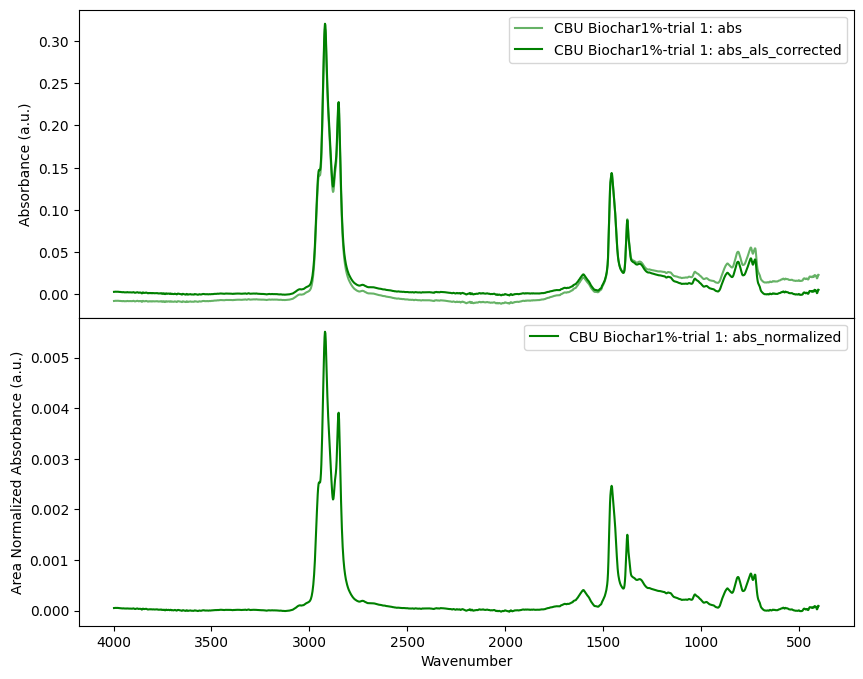

,wvn,abs,abs_als_bkg,abs_als_corrected,abs_smoothed,abs_normalized
0,398.962203,0.023050,0.017684,0.005366,0.005362,0.000092
1,401.018709,0.023373,0.017656,0.005717,0.005731,0.000099
2,403.075215,0.021604,0.017628,0.003977,0.003955,0.000068
3,405.131722,0.019489,0.017600,0.001890,0.002065,0.000036
4,407.188228,0.019024,0.017571,0.001452,0.001549,0.000027
...,...,...,...,...,...,...
1746,3989.622029,-0.007531,-0.010764,0.003232,0.003227,0.000055
1747,3991.678536,-0.007636,-0.010775,0.003140,0.003158,0.000054
1748,3993.735042,-0.007665,-0.010787,0.003122,0.003118,0.000054
1749,3995.791548,-0.007694,-0.010798,0.003104,0.003106,0.000053


In [22]:
# Example with one file
file_name = 'CBU Biochar1%-trial 1'
df = atr_dict[file_name]['data'].copy()
df = baseline_als(df, lam=1e7, n_iter=10)
df = smooth_savgol(df)
df = normalize_area(df)

corrected_col = [col for col in df.columns if col.startswith('abs_') and col.endswith('_corrected')][0]
bkg_col = corrected_col.replace('_corrected', '_bkg')
fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0)
ax[0].plot(df['wvn'], df['abs'],color='green', alpha=0.6, label=f'{file_name}: abs')
ax[0].plot(df['wvn'], df['abs_als_corrected'],color='green', alpha=1, label=f'{file_name}: abs_als_corrected')
ax[1].plot(df['wvn'], df['abs_normalized'],color='green', alpha=1, label=f'{file_name}: abs_normalized')
ax[1].set_xlabel('Wavenumber')
ax[0].set_ylabel('Absorbance (a.u.)')
ax[1].set_ylabel('Area Normalized Absorbance (a.u.)')
ax[1].invert_xaxis()
ax[0].legend()
ax[1].legend()
plt.show()

df

### Example with all files uploaded

In [34]:
atr_dict[key]['data']

,wvn,abs,abs_als_bkg,abs_als_corrected,abs_normalized
0,398.962203,0.054507,0.023168,0.031339,0.017135
1,401.018709,0.052456,0.023158,0.029298,0.010958
2,403.075215,0.052778,0.023149,0.029629,0.012075
3,405.131722,0.054562,0.023139,0.031423,0.017692
4,407.188228,0.055805,0.023130,0.032675,0.021643
...,...,...,...,...,...
1746,3989.622029,0.015205,0.006438,0.008767,0.010602
1747,3991.678536,0.015177,0.006428,0.008749,0.010529
1748,3993.735042,0.015219,0.006419,0.008800,0.010667
1749,3995.791548,0.015273,0.006409,0.008864,0.010846


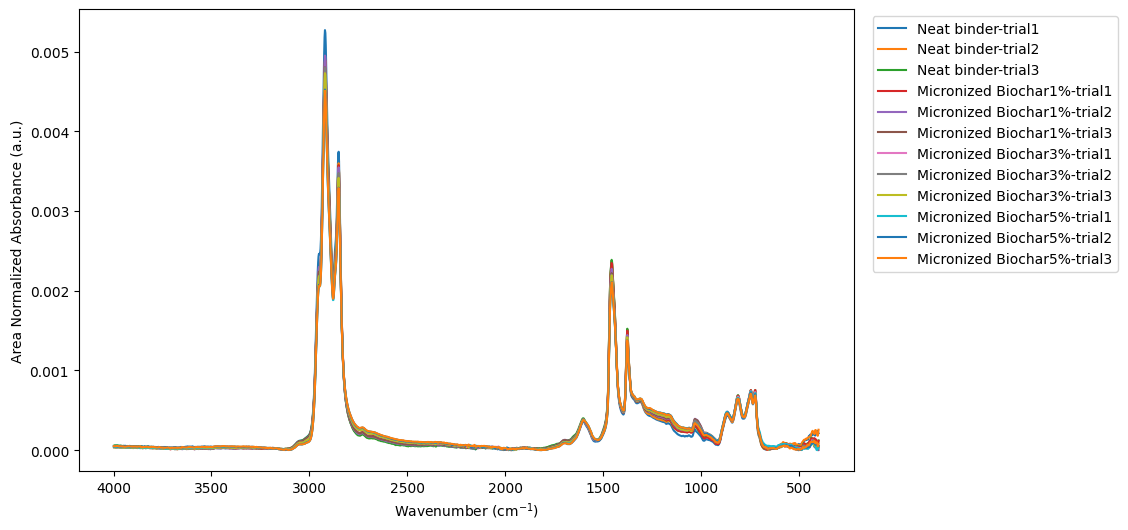

In [35]:
yaxis_name ='Absorbance (Area Normalized)'
yaxis_name ='Absorbance (MinMax)'
yaxis_name ='Norm to peak'

# Example with all files in the dictionary
for key in atr_dict:
    atr_dict[key]['data'] = baseline_als(atr_dict[key]['data'], lam=1e12, n_iter=20)
    # atr_dict[key]['data'] = smooth_savgol(atr_dict[key]['data']) # No need to smooth
    atr_dict[key]['data'] = normalize_area(atr_dict[key]['data'])
    if yaxis_name == 'Absorbance (MinMax)':
        atr_dict[key]['data'] = normalize_minmax(atr_dict[key]['data']) # this is to see the intensity ratios repective to the highest intensity
    if yaxis_name == 'Norm to peak':
        max_peak = max(atr_dict[key]['data'].iloc[:,-1][(atr_dict[key]['data']['wvn']>=800) &(atr_dict[key]['data']['wvn']<=820)])
        atr_dict[key]['data']['abs_norm_to_peak'] = atr_dict[key]['data'].iloc[:,-1]/max_peak

fig, ax = plt.subplots(figsize=(10, 6))
for key in atr_dict:
    df = atr_dict[key]['data'].copy()
    corrected_col = [col for col in df.columns if col.startswith('abs_') and col.endswith('_corrected')][0]
    bkg_col = corrected_col.replace('_corrected', '_bkg')
    ax.plot(df['wvn'], df['abs_normalized'], label=key)

ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax.set_ylabel('Area Normalized Absorbance (a.u.)')
ax.invert_xaxis()
ax.legend(bbox_to_anchor=[1.35, 1])
plt.show()

### Grouping interpolation and average

['Neat binder-trial1', 'Neat binder-trial2', 'Neat binder-trial3', 'Micronized Biochar1%-trial1', 'Micronized Biochar1%-trial2', 'Micronized Biochar1%-trial3', 'Micronized Biochar3%-trial1', 'Micronized Biochar3%-trial2', 'Micronized Biochar3%-trial3', 'Micronized Biochar5%-trial1', 'Micronized Biochar5%-trial2', 'Micronized Biochar5%-trial3']
All wavenumber grids are identical within tolerance. No interpolation needed.
All wavenumber grids are identical within tolerance. No interpolation needed.
All wavenumber grids are identical within tolerance. No interpolation needed.
All wavenumber grids are identical within tolerance. No interpolation needed.
{'label': '0pct', 'replicates': ['Neat binder-trial1', 'Neat binder-trial2', 'Neat binder-trial3']}
{'label': '1pct', 'replicates': ['Micronized Biochar1%-trial1', 'Micronized Biochar1%-trial2', 'Micronized Biochar1%-trial3']}
{'label': '3pct', 'replicates': ['Micronized Biochar3%-trial1', 'Micronized Biochar3%-trial2', 'Micronized Biochar3

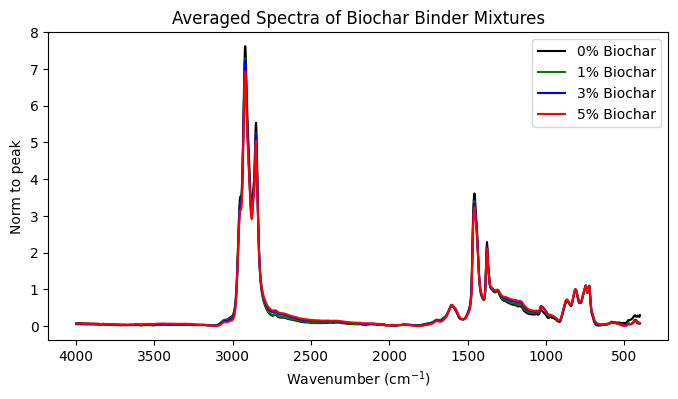

In [37]:
sample_list = [file.split('.')[0] for file in opus_files]
print(sample_list)
# Assuming your files are sorted
replicates_list1 = sample_list[:3]
replicates_list2 = sample_list[3:6]
replicates_list3 = sample_list[6:9]
replicates_list4 = sample_list[9:]

# # extract sub-dicts preserving keys
group_0pct = {k: atr_dict[k]['data'] for k in replicates_list1}
group_1pct = {k: atr_dict[k]['data'] for k in replicates_list2}
group_3pct = {k: atr_dict[k]['data'] for k in replicates_list3}
group_5pct = {k: atr_dict[k]['data'] for k in replicates_list4}

# # interpolate then average — keys preserved throughout
avg_0pct = average_replicates(interpolate_grid(group_0pct), group_label='0pct')
avg_1pct = average_replicates(interpolate_grid(group_1pct), group_label='1pct')
avg_3pct = average_replicates(interpolate_grid(group_3pct), group_label='3pct')
avg_5pct = average_replicates(interpolate_grid(group_5pct), group_label='5pct')

# metadata travels with the DataFrame
print(avg_0pct.attrs)
print(avg_1pct.attrs)
print(avg_3pct.attrs)
print(avg_5pct.attrs)

# {'label': '1pct', 'replicates': ['Biochar1%-trial 1', 'Biochar1%-trial 2', 'Biochar1%-trial 3']}

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(avg_0pct['wvn'], avg_0pct['abs_averaged'], color='black', alpha=1, label='0% Biochar')
ax.plot(avg_1pct['wvn'], avg_1pct['abs_averaged'], color='green', alpha=1, label='1% Biochar')
ax.plot(avg_3pct['wvn'], avg_3pct['abs_averaged'], color='blue', alpha=1, label='3% Biochar')
ax.plot(avg_5pct['wvn'], avg_5pct['abs_averaged'], color='red', alpha=1, label='5% Biochar')
ax.set_title('Averaged Spectra of Biochar Binder Mixtures')
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)')
ax.set_ylabel(yaxis_name)
ax.invert_xaxis()
ax.legend()
plt.show()


In [38]:
fig = go.Figure()
interp_dfs = [avg_0pct,avg_1pct,avg_3pct,avg_5pct]
N = len(interp_dfs)
rainbow_list = px.colors.sample_colorscale("Rainbow", [n/(N-1) for n in range(N)])

for i, avg_df in enumerate(interp_dfs):
    print(f"Sample group: {avg_df.attrs['label']}, Replictes: {avg_df.attrs['replicates']}")
    color = rainbow_list[i]
    x = avg_df['wvn']
    mean = avg_df['abs_averaged']
    std = avg_df['abs_std']
    label = avg_df.attrs['label']
    fig.add_trace(go.Scatter(x=x, y=mean, 
                    mode='lines',
                    name=label,
                    line=dict(color=color)),
                    )
    fig.add_trace(go.Scatter(
        x=pd.concat([x, x[::-1]]),
        y=pd.concat([mean + std, (mean - std)[::-1]]),
        fill='toself',
        fillcolor=color,
        opacity=0.2,
        line=dict(color='rgba(0,0,0,0)'),
        name=f"{label} ±std",
    ))

fig.update_layout(
    width=1000,
    height=400,
    xaxis=dict(autorange="reversed",
               title='Wavenumber (cm<sup>-1</sup>)'),
    yaxis=dict(title=yaxis_name),
    template='plotly_white',
    margin=dict(l=50, r=50, t=50, b=50),
)

# fig.write_html(f"C:/Users/brian/Downloads/Moein_Micronized2.html",
#                     default_width = 1280, default_height = 720,
#                     include_plotlyjs='cdn',   # loads Plotly from CDN instead of embedding it (~3MB saved)
#                     full_html=True)

fig.show()


Sample group: 0pct, Replictes: ['Neat binder-trial1', 'Neat binder-trial2', 'Neat binder-trial3']
Sample group: 1pct, Replictes: ['Micronized Biochar1%-trial1', 'Micronized Biochar1%-trial2', 'Micronized Biochar1%-trial3']
Sample group: 3pct, Replictes: ['Micronized Biochar3%-trial1', 'Micronized Biochar3%-trial2', 'Micronized Biochar3%-trial3']
Sample group: 5pct, Replictes: ['Micronized Biochar5%-trial1', 'Micronized Biochar5%-trial2', 'Micronized Biochar5%-trial3']


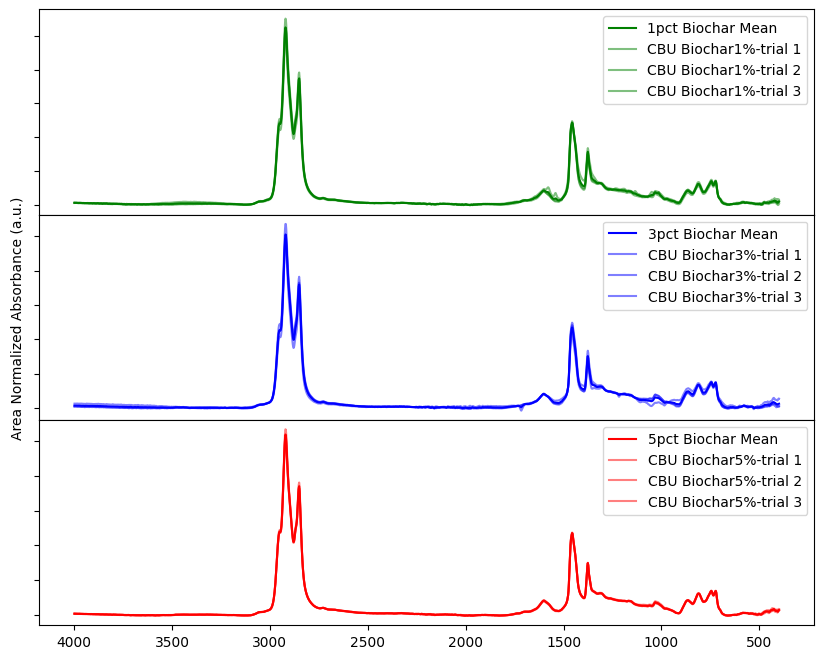

In [61]:
nrows = 3
fig, ax = plt.subplots(nrows=nrows, ncols=1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0)

for i, (avg_df,color) in enumerate(zip([avg_1pct, avg_3pct, avg_5pct], ['green', 'blue', 'red'])):
    ax[i].plot(avg_df['wvn'], avg_df['abs_averaged'], color=color, alpha=1, label=f"{avg_df.attrs['label']} Biochar Mean")
    for replicate in avg_df.attrs['replicates']:
        df = atr_dict[replicate]['data'].copy()
        ax[i].plot(df['wvn'], df['abs_normalized'], color=color, alpha=0.5, label=replicate)
    ax[i].invert_xaxis()
    ax[i].legend()
    ax[i].set_yticklabels([])
ax[1].set_ylabel('Area Normalized Absorbance (a.u.)')

plt.show()


### Build the perturbation matrix

In [106]:
matrix_df = build_spectra_matrix(
    spectra_list=[avg_1pct, avg_3pct, avg_5pct],
)


labels = [label for label in matrix_df.columns if label != 'wvn']
n = len(labels)

# 1. Generate colors using Plotly's built-in Winter scale
# sample_colorscale sample positions from 0.0 to 1.0
colors = px.colors.sample_colorscale("thermal", np.linspace(0, 1, n))

# 2. Build the figure
fig = go.Figure()

for label, color in zip(labels, colors):
    fig.add_trace(
        go.Scatter(
            x=matrix_df["wvn"],
            y=matrix_df[label],
            name=label,
            mode="lines",
            line=dict(color=color, width=2),
            opacity=0.6,
        )
    )

# 3. Apply layouts, labels, and invert the X-axis
fig.update_layout(
    title='''Averaged ATR spectra by Biochar Percentage in binder <br>'''
    '''(Baseline Corrected ALS, Area Normalized)''',
    xaxis_title="Wavenumber",
    yaxis_title="Absorbance",
    xaxis=dict(autorange="reversed"),  # Inverts the x-axis
    width=800,
    height=500,
    template="plotly_white",
)

fig.show()

matrix_df.head()

All wavenumber grids are identical within tolerance. No interpolation needed.


,wvn,1pct,3pct,5pct
0,398.962203,0.000086,0.000129,0.000154
1,401.018709,0.000078,0.000127,0.000142
2,403.075215,0.000070,0.000122,0.000119
3,405.131722,0.000060,0.000115,0.000109
4,407.188228,0.000055,0.000109,0.000121


In [107]:
dynamic_df = compute_dynamic_spectra(matrix_df)

n = len(dynamic_df.columns) - 1  

# 1. Generate colors using Plotly's built-in Winter scale
# sample_colorscale sample positions from 0.0 to 1.0
colors = px.colors.sample_colorscale("thermal", np.linspace(0, 1, n))

# 2. Build the figure
fig = go.Figure()

for label, color in zip(dynamic_df.columns[1:], colors):
    fig.add_trace(
        go.Scatter(
            x=dynamic_df["wvn"],
            y=dynamic_df[label],
            name=label,
            mode="lines",
            line=dict(color=color, width=2),
            opacity=0.6,
        )
    )

# 3. Apply layouts, labels, and invert the X-axis
fig.update_layout(
    title="Dynamic Spectra by Perturbation Level",
    xaxis_title="Wavenumber",
    yaxis_title="Absorbance",
    xaxis=dict(autorange="reversed"),  # Inverts the x-axis
    width=800,
    height=500,
    template="plotly_white",
)

# To view the plot in a notebook
fig.show()

dynamic_df.head()

,wvn,dyn_1pct,dyn_3pct,dyn_5pct
0,398.962203,-0.000037,0.000006,0.000031
1,401.018709,-0.000037,0.000011,0.000026
2,403.075215,-0.000034,0.000018,0.000015
3,405.131722,-0.000034,0.000020,0.000014
4,407.188228,-0.000040,0.000014,0.000026


In [108]:
sync_df, async_df = compute_2dcos(dynamic_df)

C:\Users\brian\AppData\Local\Temp\ipykernel_18652\2815789420.py:105: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



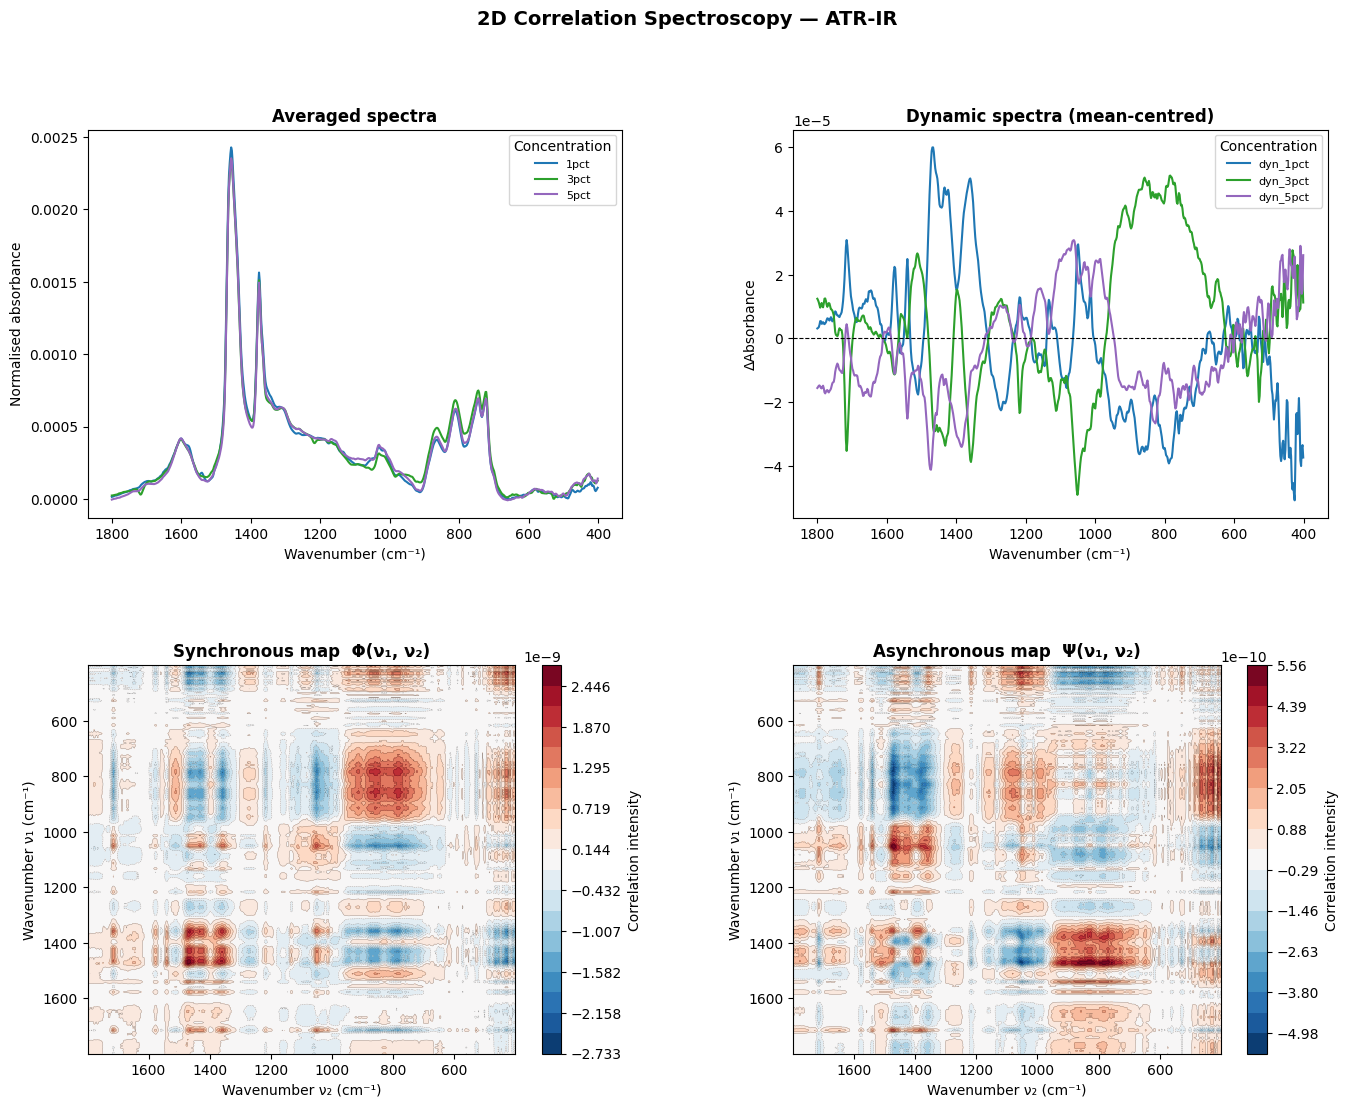

In [109]:
def plot_2dcos(
    sync_df: pd.DataFrame,
    async_df: pd.DataFrame,
    matrix_df: pd.DataFrame,
    dynamic_df: pd.DataFrame,
    n_levels: int = 20,
    cmap: str = 'RdBu_r',
    wvn_range: tuple[float, float] | None = None,
    save_path: str | None = None,
) -> None:
    """
    4-panel 2D-COS dashboard:
        [0] Averaged spectra per concentration grade
        [1] Dynamic spectra (mean-centred)
        [2] Synchronous map Φ
        [3] Asynchronous map Ψ

    Parameters
    ----------
    sync_df    : synchronous map DataFrame (output of compute_2dcos)
    async_df   : asynchronous map DataFrame (output of compute_2dcos)
    matrix_df  : averaged spectra matrix (output of build_spectra_matrix)
    dynamic_df : dynamic spectra (output of compute_dynamic_spectra)
    n_levels   : number of contour levels
    cmap       : colormap — 'RdBu_r' keeps red=positive, blue=negative
    wvn_range  : optional (min, max) tuple to zoom into a spectral region
    save_path  : optional file path to save the figure, e.g. '2dcos.png'
    """

    # ── optional wavenumber range crop ──────────────────────────────────────
    def crop(df, is_map=False):
        if wvn_range is None:
            return df
        lo, hi = wvn_range
        if is_map:
            mask = (df.index >= lo) & (df.index <= hi)
            return df.loc[mask, df.columns[mask]]
        else:
            mask = (df['wvn'] >= lo) & (df['wvn'] <= hi)
            return df.loc[mask].reset_index(drop=True)

    matrix_plot  = crop(matrix_df)
    dynamic_plot = crop(dynamic_df)
    sync_plot    = crop(sync_df,  is_map=True)
    async_plot   = crop(async_df, is_map=True)

    wvn          = matrix_plot['wvn'].to_numpy()
    spec_cols    = [c for c in matrix_plot.columns  if c != 'wvn']
    dyn_cols     = [c for c in dynamic_plot.columns if c != 'wvn']
    colors       = plt.cm.tab10(np.linspace(0, 0.4, len(spec_cols)))

    # ── figure layout ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 12))
    fig.subplots_adjust(hspace=0.2, wspace=0.2)
    fig.suptitle('2D Correlation Spectroscopy — ATR-IR', fontsize=14, fontweight='bold')
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

    # ── panel 0 — averaged spectra ───────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0, 0])
    for col, color in zip(spec_cols, colors):
        ax0.plot(wvn, matrix_plot[col], label=str(col), color=color, linewidth=1.5)
    ax0.set_title('Averaged spectra', fontweight='bold')
    ax0.set_xlabel('Wavenumber (cm⁻¹)')
    ax0.set_ylabel('Normalised absorbance')
    ax0.invert_xaxis()
    ax0.legend(title='Concentration', fontsize=8)

    # ── panel 1 — dynamic spectra ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 1])
    for col, color in zip(dyn_cols, colors):
        ax1.plot(wvn, dynamic_plot[col], label=str(col), color=color, linewidth=1.5)
    ax1.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax1.set_title('Dynamic spectra (mean-centred)', fontweight='bold')
    ax1.set_xlabel('Wavenumber (cm⁻¹)')
    ax1.set_ylabel('ΔAbsorbance')
    ax1.invert_xaxis()
    ax1.legend(title='Concentration', fontsize=8)

    # ── helper: contour map ──────────────────────────────────────────────────
    def plot_map(ax, df, title):
        wvn_ax = df.index.to_numpy()
        Z      = df.to_numpy()
        vmax   = np.abs(Z).max()
        levels = np.linspace(-vmax, vmax, n_levels)

        ct = ax.contourf(wvn_ax, wvn_ax, Z, levels=levels, cmap=cmap)
        ax.contour(wvn_ax, wvn_ax, Z, levels=levels,
                   colors='k', linewidths=0.3, alpha=0.4)
        plt.colorbar(ct, ax=ax, label='Correlation intensity')

        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Wavenumber ν₂ (cm⁻¹)')
        ax.set_ylabel('Wavenumber ν₁ (cm⁻¹)')
        ax.invert_xaxis()
        ax.invert_yaxis()

    # ── panel 2 — synchronous map ────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    plot_map(ax2, sync_plot, 'Synchronous map  Φ(ν₁, ν₂)')

    # ── panel 3 — asynchronous map ───────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    plot_map(ax3, async_plot, 'Asynchronous map  Ψ(ν₁, ν₂)')

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        print(f"Figure saved → {save_path}")

    plt.show()

plot_2dcos(
    sync_df    = sync_df,
    async_df   = async_df,
    matrix_df  = matrix_df,
    dynamic_df = dynamic_df,
    wvn_range  = (400, 1800),   # or None for full spectrum
    # save_path  = '2dcos.png',
)

In [110]:
def noda_rules(
    sync_df: pd.DataFrame,
    async_df: pd.DataFrame,
    nu1: float,
    nu2: float,
    tol: float = 2.0,
) -> dict:
    """
    Applies Noda's sequential order rules to a cross-peak (ν₁, ν₂).

    Finds the nearest wavenumber in the grid to the requested nu1 and nu2
    within tolerance, then reads the sign of Φ and Ψ at that cross-peak
    and returns the sequential order interpretation.

    Parameters
    ----------
    sync_df  : synchronous map DataFrame (output of compute_2dcos)
    async_df : asynchronous map DataFrame (output of compute_2dcos)
    nu1      : first wavenumber of the cross-peak (cm⁻¹)
    nu2      : second wavenumber of the cross-peak (cm⁻¹)
    tol      : maximum distance (cm⁻¹) to snap to nearest grid point

    Returns
    -------
    dict with keys:
        'nu1_found'   : actual wavenumber used for ν₁
        'nu2_found'   : actual wavenumber used for ν₂
        'phi'         : Φ value at cross-peak
        'psi'         : Ψ value at cross-peak
        'phi_sign'    : sign of Φ (+1, -1, or 0)
        'psi_sign'    : sign of Ψ (+1, -1, or 0)
        'sync_corr'   : 'positive', 'negative', or 'zero'
        'async_corr'  : 'positive', 'negative', or 'zero'
        'order'       : sequential order interpretation string
        'autopeak'    : True if nu1 == nu2 (diagonal — no async info)
    """
    wvn = sync_df.index.to_numpy()

    # ── snap to nearest grid point ───────────────────────────────────────────
    def snap(nu, label):
        idx      = np.argmin(np.abs(wvn - nu))
        distance = np.abs(wvn[idx] - nu)
        if distance > tol:
            raise ValueError(
                f"ν{label}={nu} cm⁻¹ is {distance:.2f} cm⁻¹ away from the "
                f"nearest grid point ({wvn[idx]:.2f} cm⁻¹). "
                f"Increase tol or check your wavenumber."
            )
        return wvn[idx]

    nu1_found = snap(nu1, '₁')
    nu2_found = snap(nu2, '₂')

    # ── extract values ───────────────────────────────────────────────────────
    phi = sync_df.loc[nu1_found, nu2_found]
    psi = async_df.loc[nu1_found, nu2_found]

    phi_sign = int(np.sign(phi))
    psi_sign = int(np.sign(psi))

    def sign_label(s):
        return {1: 'positive', -1: 'negative', 0: 'zero'}.get(s, 'zero')

    # ── autopeak check ───────────────────────────────────────────────────────
    if np.isclose(nu1_found, nu2_found):
        order = (f"ν₁ = ν₂ = {nu1_found:.2f} cm⁻¹ — this is a diagonal autopeak. "
                 f"Noda's rules apply to off-diagonal cross-peaks only.")
        return {
            'nu1_found': nu1_found, 'nu2_found': nu2_found,
            'phi': phi, 'psi': psi,
            'phi_sign': phi_sign, 'psi_sign': psi_sign,
            'sync_corr': sign_label(phi_sign),
            'async_corr': sign_label(psi_sign),
            'order': order,
            'autopeak': True,
        }

    # ── zero cross-peak check ────────────────────────────────────────────────
    if phi_sign == 0 or psi_sign == 0:
        order = (f"Cross-peak ({nu1_found:.2f}, {nu2_found:.2f}) cm⁻¹ — "
                 f"one or both maps are zero here. No sequential information.")

    # ── Noda's rules ─────────────────────────────────────────────────────────
    elif phi_sign > 0 and psi_sign > 0:
        order = f"ν₁ ({nu1_found:.2f} cm⁻¹) changes BEFORE ν₂ ({nu2_found:.2f} cm⁻¹)"
    elif phi_sign > 0 and psi_sign < 0:
        order = f"ν₂ ({nu2_found:.2f} cm⁻¹) changes BEFORE ν₁ ({nu1_found:.2f} cm⁻¹)"
    elif phi_sign < 0 and psi_sign > 0:
        order = f"ν₂ ({nu2_found:.2f} cm⁻¹) changes BEFORE ν₁ ({nu1_found:.2f} cm⁻¹)"
    else:  # phi < 0, psi < 0
        order = f"ν₁ ({nu1_found:.2f} cm⁻¹) changes BEFORE ν₂ ({nu2_found:.2f} cm⁻¹)"

    result = {
        'nu1_found' : nu1_found,
        'nu2_found' : nu2_found,
        'phi'       : phi,
        'psi'       : psi,
        'phi_sign'  : phi_sign,
        'psi_sign'  : psi_sign,
        'sync_corr' : sign_label(phi_sign),
        'async_corr': sign_label(psi_sign),
        'order'     : order,
        'autopeak'  : False,
    }

    # ── print summary ────────────────────────────────────────────────────────
    print(
        f"\nNoda's Rules — Cross-peak ({nu1_found:.2f}, {nu2_found:.2f}) cm⁻¹\n"
        f"{'─' * 52}\n"
        f"  Φ = {phi}  →  {sign_label(phi_sign)}\n"
        f"  Ψ = {psi}  →  {sign_label(psi_sign)}\n"
        f"  {order}\n"
        f"{'─' * 52}"
    )

    return result

In [111]:
# before calling noda_rules, check for monotonicity
def check_monotonicity(dynamic_df: pd.DataFrame, nu: float, tol: float = 2.0) -> dict:
    """
    Checks whether a band's dynamic response is monotonic
    along the perturbation axis.

    Returns a dict with the trend values and a monotonicity flag.
    """
    wvn = dynamic_df['wvn'].to_numpy()
    idx = np.argmin(np.abs(wvn - nu))

    if np.abs(wvn[idx] - nu) > tol:
        raise ValueError(f"{nu} cm⁻¹ not found within tol={tol} cm⁻¹.")

    dyn_cols = [c for c in dynamic_df.columns if c.startswith('dyn_')]
    values   = dynamic_df.iloc[idx][dyn_cols].to_numpy(dtype=float)
    diffs    = np.diff(values)

    is_monotonic = bool(np.all(diffs > 0) or np.all(diffs < 0))

    print(
        f"\nMonotonicity check — {wvn[idx]:.2f} cm⁻¹\n"
        f"{'─' * 40}\n"
        f"  Dynamic values : {np.round(values, 6)}\n"
        f"  Differences    : {np.round(diffs, 6)}\n"
        f"  Monotonic      : {is_monotonic}\n"
        f"{'─' * 40}"
    )

    return {
        'nu_found'    : wvn[idx],
        'values'      : values,
        'diffs'       : diffs,
        'is_monotonic': is_monotonic,
    }